In [3]:
import torch
from llm_from_scratch.pretraining.model.gpt import GPT

In [6]:
b = 2
context_size = 7
vocab_size = 50257

model = GPT(
    vocab_size=vocab_size,
    n_layers=2,
    d_in=4,
    context_length=context_size,
    dropout=0.1,
    n_heads=1,
    qkv_bias=True,
)

In [26]:
input_ids = torch.randint(low=0,high=vocab_size,size=(b,context_size))
print(input_ids)
print(input_ids.shape)
print(input_ids.dtype)

tensor([[29195, 29063, 32330, 19049,  6990, 22681, 27081],
        [49798, 38590, 48057, 21393, 39906, 19766, 33742]])
torch.Size([2, 7])
torch.int64


In [ ]:
# TODO (not production-ready — gaps vs lab inference):
# 1. No KV cache — recomputes attention for all tokens every step (O(n^2) cost); labs cache past K/V
# 2. No padding mask — finished sequences in a batch keep running wasted compute instead of being masked out
# 3. Repetition penalty applied via Python loop — not vectorized, slow for large batches
# 4. EOS stops entire batch — should mask finished sequences and continue for unfinished ones
# 5. No beam search — only greedy/sampling; labs support beam search for higher quality outputs
# 6. No min_new_tokens — can't prevent EOS from firing too early
# 7. No logits processors / warpers pipeline — labs have a composable filter chain (bad words, no repeat ngram, etc.)
# 8. Inference optimization: quantization (int8/int4), speculative decoding, continuous batching (vLLM/TGI)

def generate(model, input_ids, max_new_tokens, context_size, temperature=1.0, top_k=None, top_p=None, eos_token_id=None, repetition_penalty=1.0):

    # input_ids  # (b, prompt_input_tokens)
    for _ in range(max_new_tokens):
        # input_ids can contain many more tokens than the context size. For predictions, get the context size worth of tokens from the last since the model can only handle that
        input_cond = input_ids[:, -context_size:]  # (b, context_size)
        with torch.no_grad():
            logits = model(input_cond)  # (b, context_size, vocab_size)

        # logits[:, -1, :]  # (b,vocab_size) => all logits for the vocab_size neurons at the last token index. Middle index collapses automatically since we reference a single index
        logits_last_token = logits[:, -1, :]
        if repetition_penalty != 1.0:
            for b_idx in range(input_ids.shape[0]):
                for token_id in input_ids[b_idx].tolist():
                    logits_last_token[b_idx, token_id] /= repetition_penalty

        if temperature == 0:  # apply greedy
            # torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)  # chooses the token index with max value across the batch. Collapses to shape (b) unless keepdim is passed as true which makes it (b,1)
            token_next = torch.argmax(logits_last_token, dim=-1, keepdim=True)  # (b, 1)
        else:   # sample from prob distribution
            logits_last_token = logits_last_token / temperature

            if top_k:
                top_k_vals = torch.topk(logits_last_token, top_k, dim=-1).values
                top_k_vals_smallest = top_k_vals[...,-1,None]  # ... makes the shape invariant. -1 selects the last tensor in each batch. None adds a dimension in the end for broadcasting
                logits_last_token[logits_last_token < top_k_vals_smallest] = float('-inf')  # inplace modification
            
            if top_p:
                sorted_logits_last_token, sorted_idx = torch.sort(logits_last_token, descending=True, dim=-1)  # sort and store values and indices
                cum_probs = torch.cumsum(torch.softmax(sorted_logits_last_token, dim=-1), dim=-1)  # create prob and do cumulative sum
                # remove tokens once cumulative prob exceeds top_p
                sorted_logits_last_token[cum_probs - torch.softmax(sorted_logits_last_token, dim=-1) >= top_p] = float('-inf')
                logits_last_token = sorted_logits_last_token.scatter(-1, sorted_idx, sorted_logits_last_token)  # -1 is the dimension. Scatters back the data to the right places using vals and indices
            
            # torch.softmax(logits[:, -1, :], dim=-1, keepdim=True)  # same shape. Converts to a prob dist
            dist = torch.softmax(logits_last_token, dim=-1)  # creates a prob distribution
            token_next = torch.multinomial(dist, num_samples=1)  # samples from the prob distribution which is a multinomial distribution => (b, 1)
            
        input_ids = torch.cat((input_ids, token_next), dim=-1)  # torch.cat((b,x), (b,1)) with dim==-1 => (b,x+1)
        if eos_token_id is not None and (token_next == eos_token_id).all():
            break
    return input_ids

In [113]:
model.eval()
generate(model, input_ids, 1, context_size, temperature=2)

tensor([[29195, 29063, 32330, 19049,  6990, 22681, 27081,  4138],
        [49798, 38590, 48057, 21393, 39906, 19766, 33742, 29384]])

# Visualizing temperature

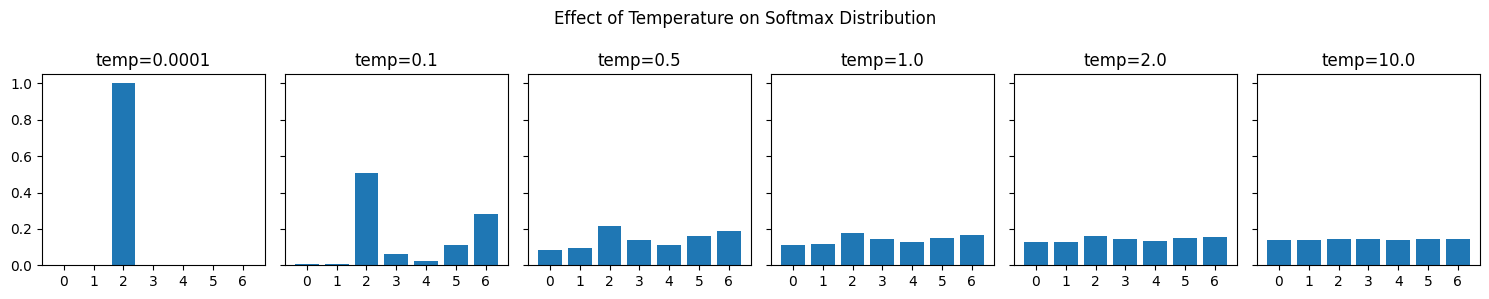

In [134]:
import matplotlib.pyplot as plt
import torch

torch.manual_seed(121)
logits = torch.rand(size=(1, 7))

temperatures = [0.0001, 0.1, 0.5, 1.0, 2.0, 10.0]
dist = lambda t: torch.softmax(logits / t, dim=-1).squeeze().numpy()

fig, axes = plt.subplots(1, len(temperatures), figsize=(15, 3), sharey=True)
for ax, t in zip(axes, temperatures):
    ax.bar(range(7), dist(t))
    ax.set_title(f"temp={t}")
    ax.set_xticks(range(7))

plt.suptitle("Effect of Temperature on Softmax Distribution")
plt.tight_layout()
plt.show()

Higher the temperature, flatter  the softmax distribution => more unpredictable the outputs

# Visualizing topk

In [178]:
import matplotlib.pyplot as plt
import torch

torch.manual_seed(121)
logits = torch.rand(size=(2, 7))
print(f"logits: {logits}")

top_k = torch.topk(logits, 3, dim=-1)
print(f"top_k values: {top_k.values}")
print(f"top_k values without end dimension: {top_k.values[..., -1].shape}")
print(f"top_k values with end dimension: {top_k.values[..., -1, None].shape}")

print(f"topk mask: {logits < top_k.values[..., -1, None]}")

logits[logits < top_k.values[..., -1, None]] = float('-inf')
print(f"logits post top k -inf conversion {logits}")

print(f"softmax topk: {torch.softmax(logits, dim=-1)}")

logits: tensor([[0.5007, 0.5530, 0.9565, 0.7496, 0.6384, 0.8077, 0.8978],
        [0.5601, 0.5256, 0.7400, 0.4274, 0.3456, 0.2824, 0.6465]])
top_k values: tensor([[0.9565, 0.8978, 0.8077],
        [0.7400, 0.6465, 0.5601]])
top_k values without end dimension: torch.Size([2])
top_k values with end dimension: torch.Size([2, 1])
topk mask: tensor([[ True,  True, False,  True,  True, False, False],
        [False,  True, False,  True,  True,  True, False]])
logits post top k -inf conversion tensor([[  -inf,   -inf, 0.9565,   -inf,   -inf, 0.8077, 0.8978],
        [0.5601,   -inf, 0.7400,   -inf,   -inf,   -inf, 0.6465]])
softmax topk: tensor([[0.0000, 0.0000, 0.3565, 0.0000, 0.0000, 0.3073, 0.3362],
        [0.3042, 0.0000, 0.3642, 0.0000, 0.0000, 0.0000, 0.3317]])


# Visualizing top_p

In [175]:
top_p = 0.5

torch.manual_seed(121)
logits = torch.rand(size=(2, 7))
print(f"logits: \n{logits}")

sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
print(f"sorted logits: \n{sorted_logits}")
print(f"sorted idx: \n{sorted_idx}")

cum_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)
print(f"cum_probs: \n{cum_probs}")
print(f"probs: \n{torch.softmax(sorted_logits, dim=-1)}")

print(f"Right Shift cumsum: \n{cum_probs - torch.softmax(sorted_logits, dim=-1)}")
print(f"top_p Mask: \n{cum_probs - torch.softmax(sorted_logits, dim=-1) >= top_p}")

sorted_logits[cum_probs - torch.softmax(sorted_logits, dim=-1) >= top_p] = float('-inf')
logits = sorted_logits.scatter(-1, sorted_idx, sorted_logits)
print(logits)


logits: 
tensor([[0.5007, 0.5530, 0.9565, 0.7496, 0.6384, 0.8077, 0.8978],
        [0.5601, 0.5256, 0.7400, 0.4274, 0.3456, 0.2824, 0.6465]])
sorted logits: 
tensor([[0.9565, 0.8978, 0.8077, 0.7496, 0.6384, 0.5530, 0.5007],
        [0.7400, 0.6465, 0.5601, 0.5256, 0.4274, 0.3456, 0.2824]])
sorted idx: 
tensor([[2, 6, 5, 3, 4, 1, 0],
        [2, 6, 0, 1, 3, 4, 5]])
cum_probs: 
tensor([[0.1771, 0.3441, 0.4967, 0.6406, 0.7695, 0.8877, 1.0000],
        [0.1788, 0.3417, 0.4911, 0.6355, 0.7663, 0.8868, 1.0000]])
probs: 
tensor([[0.1771, 0.1670, 0.1526, 0.1440, 0.1288, 0.1183, 0.1123],
        [0.1788, 0.1629, 0.1494, 0.1443, 0.1308, 0.1206, 0.1132]])
Right Shift cumsum: 
tensor([[0.0000, 0.1771, 0.3441, 0.4967, 0.6406, 0.7695, 0.8877],
        [0.0000, 0.1788, 0.3417, 0.4911, 0.6355, 0.7663, 0.8868]])
top_p Mask: 
tensor([[False, False, False, False,  True,  True,  True],
        [False, False, False, False,  True,  True,  True]])
tensor([[  -inf,   -inf, 0.9565, 0.7496,   -inf, 0.8077, 0.89